In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q transformers==4.52.4 datasets==3.6.0 accelerate==1.7.0 sentencepiece evaluate openpyxl torchvision==0.22.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.1/362.1 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 124.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 855.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5

In [3]:
import torch
import transformers
import datasets
import torchvision

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Torchvision:", torchvision.__version__)

Torch: 2.7.1+cu126
Transformers: 4.52.4
Datasets: 3.6.0
Torchvision: 0.22.1+cu126


In [4]:
from torchvision.io import VideoReader

print("VideoReader OK")

VideoReader OK


In [5]:
import pandas as pd

df = pd.read_excel(
    "/content/drive/MyDrive/final_dataset_v2.xlsx"
)

print(df.shape)

(31310, 4)


In [6]:
label_map = {
    "Remember": 0,
    "Understand": 1,
    "Apply": 2,
    "Analyze": 3,
    "Evaluate": 4,
    "Create": 5
}

df["label"] = df["Bloom_Level"].map(label_map)

print(df["label"].value_counts().sort_index())

label
0    3810
1    5818
2    4652
3    4831
4    5485
5    6714
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

print(train_df.shape)
print(val_df.shape)

(25048, 5)
(6262, 5)


In [8]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "microsoft/deberta-v3-base"
)

print("Tokenizer Loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Tokenizer Loaded


In [9]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["Question","label"]]
)

val_dataset = Dataset.from_pandas(
    val_df[["Question","label"]]
)

print(train_dataset)
print(val_dataset)

Dataset({
    features: ['Question', 'label', '__index_level_0__'],
    num_rows: 25048
})
Dataset({
    features: ['Question', 'label', '__index_level_0__'],
    num_rows: 6262
})


In [10]:
def tokenize_function(examples):

    return tokenizer(
        examples["Question"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [11]:
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/25048 [00:00<?, ? examples/s]

Map:   0%|          | 0/6262 [00:00<?, ? examples/s]

In [12]:
train_dataset = train_dataset.rename_column(
    "label",
    "labels"
)

val_dataset = val_dataset.rename_column(
    "label",
    "labels"
)

In [13]:
train_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels"
    ]
)

val_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels"
    ]
)

print(train_dataset[0].keys())

dict_keys(['labels', 'input_ids', 'attention_mask'])


In [14]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-base",
    num_labels=6
)

print(model.dtype)

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


torch.float32


In [15]:
import torch

sample = tokenizer(
    "What is a primary key?",
    return_tensors="pt"
)

with torch.no_grad():
    output = model(**sample)

print(output.logits)

tensor([[ 0.0378,  0.0334, -0.0409, -0.0804,  0.0722, -0.1408]])


In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(pred):

    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )

    acc = accuracy_score(
        labels,
        preds
    )

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [17]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [18]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/deberta_bloom_model",

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=2,

    save_safetensors=True,

    report_to="none"
)

In [19]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer Ready")

Trainer Ready


In [20]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.405800,0.195943,0.960236,0.960440,0.961174,0.960236
2,0.117400,0.130253,0.974449,0.974519,0.974982,0.974449
3,0.063800,0.082920,0.986266,0.986267,0.986276,0.986266
4,0.036000,0.080706,0.988183,0.988188,0.988198,0.988183
5,0.018900,0.078999,0.988662,0.988658,0.988663,0.988662


TrainOutput(global_step=7830, training_loss=0.1283733102401402, metrics={'train_runtime': 4315.4235, 'train_samples_per_second': 29.021, 'train_steps_per_second': 1.814, 'total_flos': 8238450745405440.0, 'train_loss': 0.1283733102401402, 'epoch': 5.0})

In [21]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.07899933308362961, 'eval_accuracy': 0.9886617694027467, 'eval_f1': 0.9886575880029662, 'eval_precision': 0.9886631335052287, 'eval_recall': 0.9886617694027467, 'eval_runtime': 66.7455, 'eval_samples_per_second': 93.819, 'eval_steps_per_second': 5.873, 'epoch': 5.0}


In [22]:
predictions = trainer.predict(val_dataset)

In [23]:
from sklearn.metrics import confusion_matrix
import numpy as np

preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

cm = confusion_matrix(labels, preds)

print(cm)

[[ 754    2    2    3    1    0]
 [   5 1138    6    8    6    1]
 [   1   11  915    2    0    1]
 [   2    3    4  955    1    1]
 [   1    1    2    0 1093    0]
 [   0    1    2    1    3 1336]]


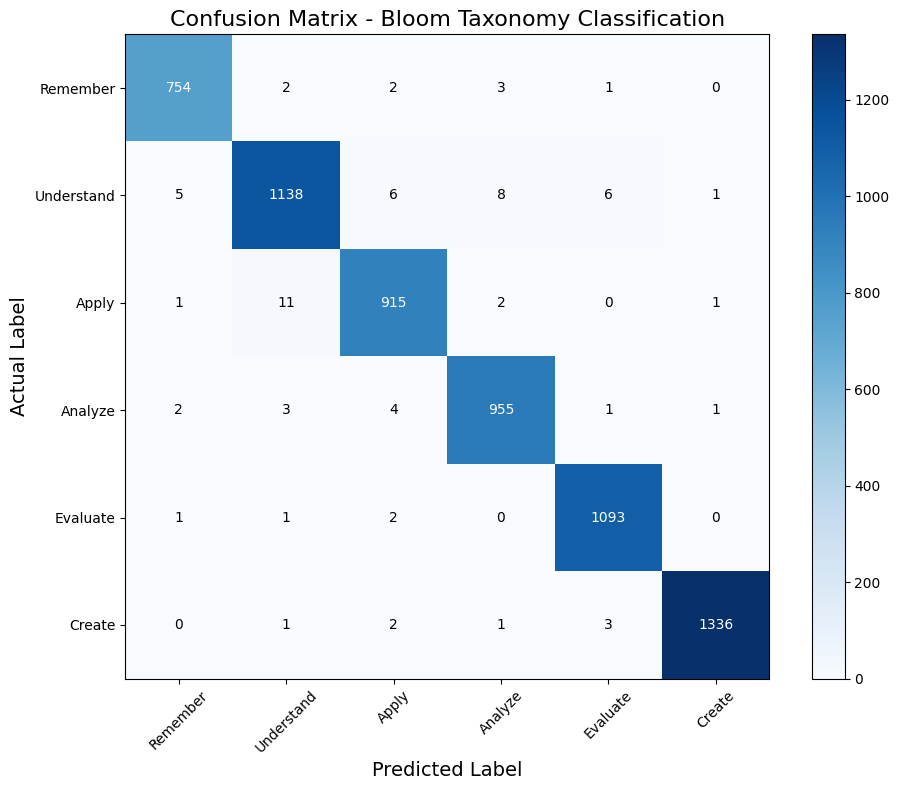

In [24]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Predictions
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# Confusion Matrix
cm = confusion_matrix(labels, preds)

# Bloom Labels
class_names = [
    "Remember",
    "Understand",
    "Apply",
    "Analyze",
    "Evaluate",
    "Create"
]

# Plot
plt.figure(figsize=(10,8))

plt.imshow(cm, interpolation='nearest', cmap='Blues')

plt.title("Confusion Matrix - Bloom Taxonomy Classification", fontsize=16)

plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Write values inside boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max()/2 else "black"
        )

plt.ylabel("Actual Label", fontsize=14)
plt.xlabel("Predicted Label", fontsize=14)

plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

class_names = [
    "Remember",
    "Understand",
    "Apply",
    "Analyze",
    "Evaluate",
    "Create"
]

report = classification_report(
    labels,
    preds,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print(report_df)

              precision    recall  f1-score      support
Remember       0.988204  0.989501  0.988852   762.000000
Understand     0.984429  0.977663  0.981034  1164.000000
Apply          0.982814  0.983871  0.983342   930.000000
Analyze        0.985552  0.988613  0.987080   966.000000
Evaluate       0.990036  0.996354  0.993185  1097.000000
Create         0.997760  0.994788  0.996271  1343.000000
accuracy       0.988662  0.988662  0.988662     0.988662
macro avg      0.988133  0.988465  0.988294  6262.000000
weighted avg   0.988663  0.988662  0.988658  6262.000000


In [26]:
report_df.to_excel(
    "/content/drive/MyDrive/deberta_bloom_model/classification_report.xlsx"
)

print("Classification Report Saved")

Classification Report Saved


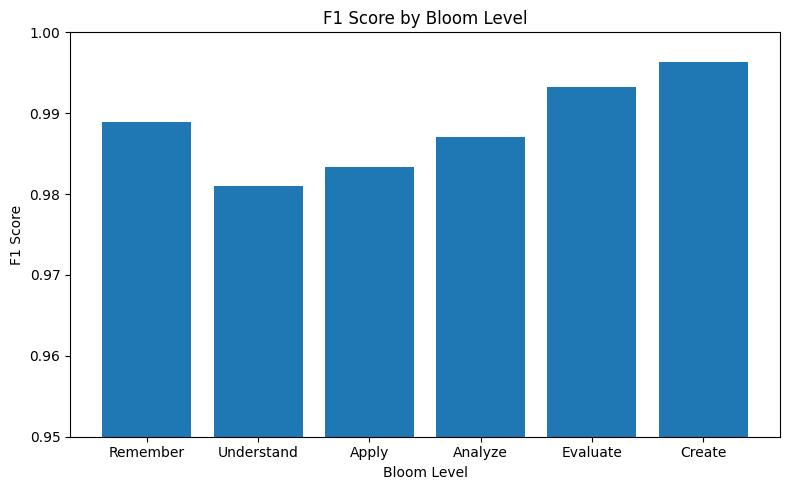

In [27]:
import matplotlib.pyplot as plt

f1_scores = report_df.loc[class_names, "f1-score"]

plt.figure(figsize=(8,5))

plt.bar(class_names, f1_scores)

plt.title("F1 Score by Bloom Level")
plt.ylabel("F1 Score")
plt.xlabel("Bloom Level")

plt.ylim(0.95, 1.00)

plt.tight_layout()
plt.show()

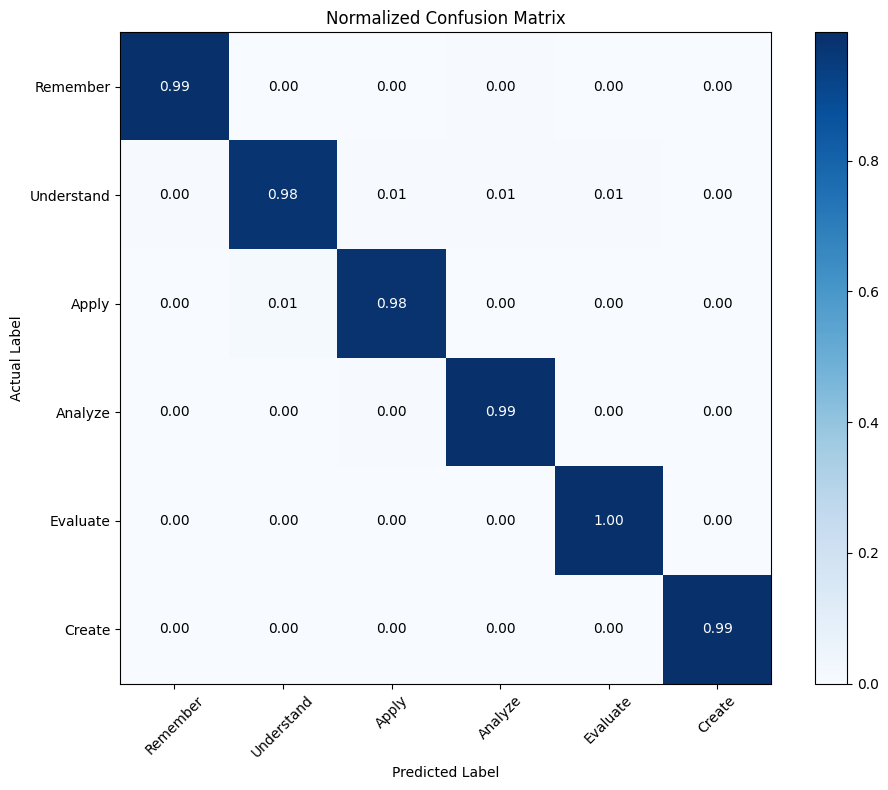

In [28]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

class_names = [
    "Remember",
    "Understand",
    "Apply",
    "Analyze",
    "Evaluate",
    "Create"
]

plt.figure(figsize=(10,8))

plt.imshow(cm_normalized, interpolation='nearest', cmap='Blues')

plt.title("Normalized Confusion Matrix")

plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm_normalized.shape[0]):
    for j in range(cm_normalized.shape[1]):
        plt.text(
            j,
            i,
            f"{cm_normalized[i,j]:.2f}",
            ha="center",
            va="center",
            color="white" if cm_normalized[i,j] > 0.5 else "black"
        )

plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")

plt.tight_layout()
plt.show()

In [29]:
plt.savefig(
    "/content/drive/MyDrive/deberta_bloom_model/normalized_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

print("Normalized Confusion Matrix Saved")

Normalized Confusion Matrix Saved


<Figure size 640x480 with 0 Axes>

In [30]:
epochs = [1,2,3,4,5]

accuracy = [
    0.960236,
    0.974449,
    0.986266,
    0.988183,
    0.988662
]

f1 = [
    0.960440,
    0.974519,
    0.986267,
    0.988188,
    0.988658
]

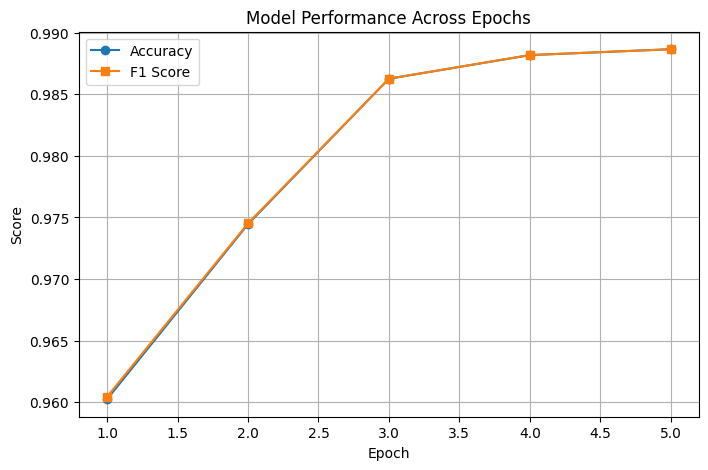

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(epochs, accuracy, marker='o', label='Accuracy')
plt.plot(epochs, f1, marker='s', label='F1 Score')

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Model Performance Across Epochs")

plt.legend()
plt.grid(True)

plt.show()

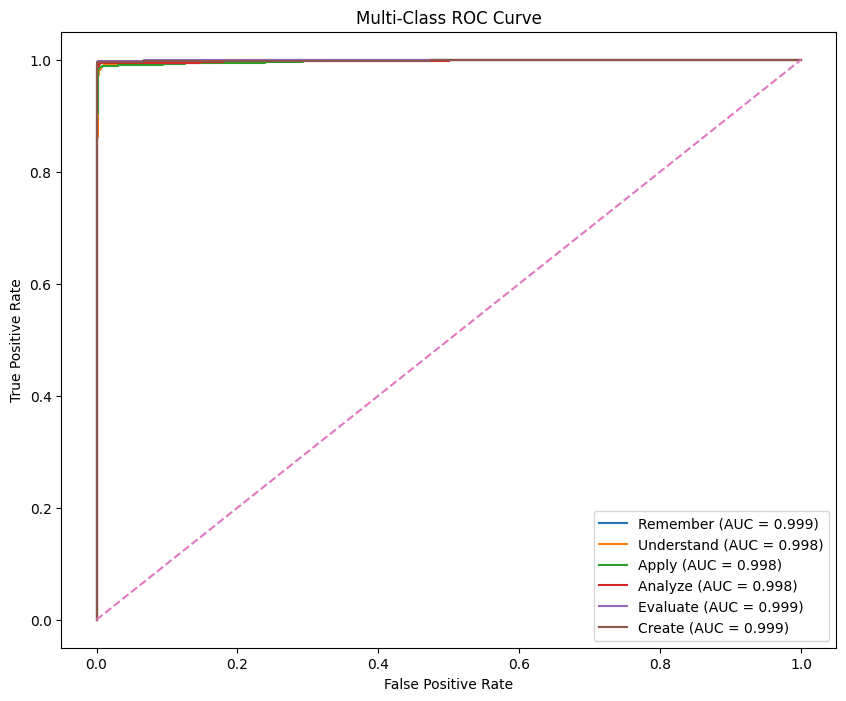

In [32]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

y_true = predictions.label_ids

y_score = predictions.predictions

n_classes = 6

y_true_bin = label_binarize(
    y_true,
    classes=[0,1,2,3,4,5]
)

plt.figure(figsize=(10,8))

class_names = [
    "Remember",
    "Understand",
    "Apply",
    "Analyze",
    "Evaluate",
    "Create"
]

for i in range(n_classes):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")

plt.legend(loc="lower right")

plt.show()

In [33]:
plt.savefig(
    "/content/drive/MyDrive/deberta_bloom_model/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [34]:
import os

folder = "/content/drive/MyDrive/deberta_bloom_model"

for file in os.listdir(folder):
    print(file)

checkpoint-6264
checkpoint-7830
classification_report.xlsx
normalized_confusion_matrix.png
roc_curve.png


In [38]:
import os

model_path = "/content/drive/MyDrive/deberta_bloom_model/final_model"

total_size = 0

for dirpath, dirnames, filenames in os.walk(model_path):
    for f in filenames:
        fp = os.path.join(dirpath, f)
        total_size += os.path.getsize(fp)

print(f"Model Size: {total_size / (1024**2):.2f} MB")

Model Size: 714.17 MB


In [36]:
trainer.save_model(
    "/content/drive/MyDrive/deberta_bloom_model/final_model"
)

tokenizer.save_pretrained(
    "/content/drive/MyDrive/deberta_bloom_model/final_model"
)

print("Model Saved Successfully")

Model Saved Successfully


In [37]:
import os

for f in os.listdir("/content/drive/MyDrive/deberta_bloom_model/final_model"):
    print(f)

config.json
model.safetensors
tokenizer_config.json
special_tokens_map.json
added_tokens.json
spm.model
tokenizer.json
training_args.bin


In [39]:
os.listdir("/content/drive/MyDrive/deberta_bloom_model/final_model")

['config.json',
 'model.safetensors',
 'tokenizer_config.json',
 'special_tokens_map.json',
 'added_tokens.json',
 'spm.model',
 'tokenizer.json',
 'training_args.bin']

In [40]:
import shutil

shutil.make_archive(
    "/content/deberta_bloom_model",
    "zip",
    "/content/drive/MyDrive/deberta_bloom_model/final_model"
)

print("ZIP Created")

ZIP Created


In [41]:
from google.colab import files

files.download(
    "/content/deberta_bloom_model.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
import shutil

shutil.copy(
    "/content/deberta_bloom_model.zip",
    "/content/drive/MyDrive/deberta_bloom_model.zip"
)

print("ZIP Saved To Drive")

ZIP Saved To Drive


In [43]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

model_path = "/content/drive/MyDrive/deberta_bloom_model/final_model"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

label_map = {
    0: "Remember",
    1: "Understand",
    2: "Apply",
    3: "Analyze",
    4: "Evaluate",
    5: "Create"
}

questions = [

    # Remember
    "Define normalization.",
    "What is a primary key?",
    "List the layers of the OSI model.",
    "State the purpose of a compiler.",
    "What is deadlock in operating systems?",

    # Understand
    "Explain the purpose of normalization in databases.",
    "Describe how a hash table stores data.",
    "Explain why indexing improves query performance.",
    "Summarize the role of the transport layer.",
    "Explain how process scheduling improves CPU utilization.",

    # Apply
    "Use Dijkstra's algorithm to find the shortest path in the given graph.",
    "Apply normalization techniques to remove redundancy from the schema.",
    "Demonstrate how binary search locates an element in a sorted array.",
    "Use inheritance to implement a student management system.",
    "Apply the paging technique to manage virtual memory.",

    # Analyze
    "Analyze the impact of cache misses on processor performance.",
    "Analyze the causes of network congestion in a large enterprise network.",
    "Differentiate between deadlock prevention and deadlock avoidance.",
    "Analyze the relationship between throughput and response time.",
    "Examine how normalization affects database performance.",

    # Evaluate
    "Evaluate whether cloud computing is suitable for banking applications.",
    "Assess the effectiveness of round robin scheduling for real time systems.",
    "Critique the use of denormalization in large databases.",
    "Determine whether a linked list is preferable to an array for this application.",
    "Judge the suitability of microservices architecture for an e-commerce platform.",

    # Create
    "Design a database schema for a hospital management system.",
    "Develop a secure authentication mechanism for an online banking application.",
    "Create an algorithm to detect fraudulent transactions.",
    "Construct a network architecture for a smart city.",
    "Design a compiler optimization technique to reduce execution time."
]

for q in questions:

    inputs = tokenizer(
        q,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=1)

    pred_id = torch.argmax(probs).item()

    confidence = probs[0][pred_id].item() * 100

    print("-" * 100)
    print("Question:", q)
    print("Prediction:", label_map[pred_id])
    print(f"Confidence: {confidence:.2f}%")

----------------------------------------------------------------------------------------------------
Question: Define normalization.
Prediction: Remember
Confidence: 99.99%
----------------------------------------------------------------------------------------------------
Question: What is a primary key?
Prediction: Remember
Confidence: 99.99%
----------------------------------------------------------------------------------------------------
Question: List the layers of the OSI model.
Prediction: Remember
Confidence: 99.99%
----------------------------------------------------------------------------------------------------
Question: State the purpose of a compiler.
Prediction: Remember
Confidence: 99.99%
----------------------------------------------------------------------------------------------------
Question: What is deadlock in operating systems?
Prediction: Remember
Confidence: 99.99%
----------------------------------------------------------------------------------------------

In [45]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

model_path = "/content/drive/MyDrive/deberta_bloom_model/final_model"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

label_map = {
    0: "Remember",
    1: "Understand",
    2: "Apply",
    3: "Analyze",
    4: "Evaluate",
    5: "Create"
}

questions = [

    "Explain why cache coherence becomes difficult in multiprocessor systems.",
    "Explain why deadlock prevention may reduce system throughput.",

    "Use the Bellman Ford algorithm to compute shortest paths.",
    "Apply inheritance and polymorphism to build a banking system.",

    "Analyze the tradeoff between consistency and availability in distributed systems.",
    "Analyze why network latency increases under heavy load.",

    "Determine whether cloud deployment is preferable to on premises deployment for a hospital.",
    "Recommend the most suitable database architecture for a global e commerce platform.",
    "Judge whether microservices are appropriate for a small startup.",

    "Design a scalable recommendation engine for an online retailer.",
    "Create a fault tolerant architecture for a banking application.",

    "Compare deadlock prevention and deadlock avoidance strategies.",
    "Differentiate between process and thread scheduling.",

    "Assess the effectiveness of normalization in reducing redundancy.",
    "Evaluate the impact of caching on database performance.",

    "Construct an algorithm to detect plagiarism in student submissions.",
    "Develop a secure online examination platform.",
    "Formulate a strategy to improve cloud resource utilization."

]

for q in questions:

    inputs = tokenizer(
        q,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=1)

    pred_id = torch.argmax(probs).item()

    confidence = probs[0][pred_id].item() * 100

    print("-" * 100)
    print("Question:", q)
    print("Prediction:", label_map[pred_id])
    print(f"Confidence: {confidence:.2f}%")

----------------------------------------------------------------------------------------------------
Question: Explain why cache coherence becomes difficult in multiprocessor systems.
Prediction: Understand
Confidence: 99.46%
----------------------------------------------------------------------------------------------------
Question: Explain why deadlock prevention may reduce system throughput.
Prediction: Understand
Confidence: 99.78%
----------------------------------------------------------------------------------------------------
Question: Use the Bellman Ford algorithm to compute shortest paths.
Prediction: Apply
Confidence: 99.99%
----------------------------------------------------------------------------------------------------
Question: Apply inheritance and polymorphism to build a banking system.
Prediction: Apply
Confidence: 99.99%
----------------------------------------------------------------------------------------------------
Question: Analyze the tradeoff between con

In [47]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

model_path = "/content/drive/MyDrive/deberta_bloom_model/final_model"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

label_map = {
    0: "Remember",
    1: "Understand",
    2: "Apply",
    3: "Analyze",
    4: "Evaluate",
    5: "Create"
}

questions = [

"Explain whether cloud computing should replace traditional infrastructure.",
"Analyze how normalization improves data consistency.",
 "Design and justify a database architecture for a hospital."
]

for q in questions:

    inputs = tokenizer(
        q,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=1)

    pred_id = torch.argmax(probs).item()

    confidence = probs[0][pred_id].item() * 100

    print("-" * 100)
    print("Question:", q)
    print("Prediction:", label_map[pred_id])
    print(f"Confidence: {confidence:.2f}%")

----------------------------------------------------------------------------------------------------
Question: Explain whether cloud computing should replace traditional infrastructure.
Prediction: Understand
Confidence: 99.88%
----------------------------------------------------------------------------------------------------
Question: Analyze how normalization improves data consistency.
Prediction: Analyze
Confidence: 100.00%
----------------------------------------------------------------------------------------------------
Question: Design and justify a database architecture for a hospital.
Prediction: Create
Confidence: 100.00%
